In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.datasets import make_regression
X, y  = make_regression(n_samples=1000,n_features=2,n_targets=1,noise = 3)

In [6]:
X

array([[ 0.55351532,  0.42153428],
       [-0.296461  ,  1.4513834 ],
       [-0.04275694, -0.74617092],
       ...,
       [ 0.43823921,  0.34285548],
       [ 1.40117416, -0.47833475],
       [ 1.16078054,  0.25063435]])

In [9]:
y

array([ 1.31078904e+01,  9.00960270e+00, -6.82342088e+00,  4.84164054e+01,
       -2.17966501e+01,  1.63912983e+01,  1.04330227e-01,  2.54848813e+01,
       -3.15775795e+01,  7.14195525e+00, -1.61030201e+01,  3.29819315e+01,
        2.80511691e+01, -3.29693996e+01,  1.34792760e+01,  2.47734309e+01,
       -9.93589436e+00,  4.53795578e+01, -2.76525576e+00,  1.58402622e+01,
       -2.17715356e+01,  1.90381633e+01,  4.30632896e+00,  2.11755964e-01,
        3.60873420e+00, -1.32570833e+01, -6.61096920e+00,  4.44620381e+01,
        3.29910079e+01, -1.14416998e+01,  4.05858865e+01,  2.30337292e+01,
       -2.19505768e+01,  3.35663188e+01, -3.27750495e+01, -4.56447850e-01,
       -4.52824346e+00, -3.90121024e+01,  1.47263808e+01,  1.54935784e+01,
       -2.31195768e+01, -2.41622054e+01,  9.01250283e+00,  3.78939074e+01,
       -2.31573611e+01, -3.64538385e+01, -1.98125907e+01, -1.22186174e+01,
        1.60601898e+01,  3.88659555e+01,  6.86576450e+00,  5.62658959e+01,
       -7.25197618e+00,  

In [11]:
x = pd.DataFrame(X)
x

,0,1
0,0.553515,0.421534
1,-0.296461,1.451383
2,-0.042757,-0.746171
3,3.161451,-0.427419
4,-1.105500,-0.519135
...,...,...
995,-0.344688,0.616685
996,-0.194709,0.584260
997,0.438239,0.342855
998,1.401174,-0.478335


<Axes: xlabel='0', ylabel='1'>

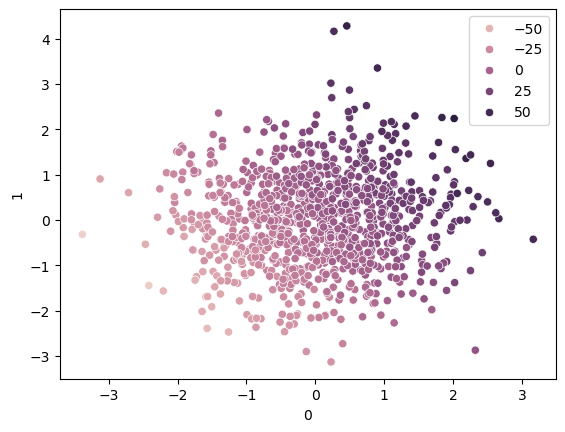

In [13]:
sns.scatterplot(x = pd.DataFrame(x)[0], y = pd.DataFrame(X)[1],hue = y)

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30, random_state = 1)

In [21]:
X_train.shape,X_test.shape

((700, 2), (300, 2))

In [32]:
from sklearn.svm import SVR
svr = SVR(kernel = "linear")
svr

SVR(kernel='linear')

In [34]:
svr.fit(X_train,y_train)

SVR(kernel='linear')

In [36]:
svr.coef_

array([[17.33451706, 10.6589979 ]])

In [42]:
y_pred = svr.predict(X_test)
y_pred

array([ 1.97396206e+01,  4.06936937e-01, -2.11069321e+01,  1.28587722e+01,
        1.76375742e+01, -1.16958091e+01, -1.94624379e+01,  1.51284196e+01,
       -3.88521207e+01,  4.00924452e+01, -3.92773137e+01, -8.33657766e+00,
       -3.78962879e+01, -4.52017605e-01, -1.47073393e+01,  2.53127647e+01,
        2.87919555e+01, -2.39130735e+00,  1.93108995e+01, -3.99719546e+01,
       -2.04656203e+01,  6.12820334e+00, -3.24505419e+01,  5.35086625e+00,
        2.21908063e+01, -1.54049935e-01,  5.13441903e+00,  2.21444418e+01,
        1.31816121e+01, -1.76863660e+01,  3.79964145e+00,  2.29797540e+01,
        4.84930470e+00,  2.68747835e+01,  1.83518689e+01,  2.79723878e+01,
        4.50788971e+01,  1.38522467e+01,  3.03458721e+00,  3.65175053e+01,
        2.81882215e+00,  2.49927738e+01,  2.03660003e-01,  3.45116095e+01,
        1.25638299e+01, -1.58417826e+01,  9.11975043e-01, -2.95277615e+01,
       -2.24690514e+01,  8.07630490e-01, -2.85205647e+01, -3.37173360e+01,
        4.41571829e+01, -

In [48]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9784101338811855

In [52]:
#hyperparameter tuning with SVR

from sklearn.model_selection import GridSearchCV
params = {'C': [1,2,3,10,50,100,120],
          'gamma': [1,0.1,0.2,0.001,0.003],
          'kernel': ['linear'],
          'epsilon': [0.01,0.1,0.2,0.3]}

grid = GridSearchCV(SVR(),param_grid = params, cv=5, verbose=3)
grid

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 2, 3, 10, 50, 100, 120],
                         'epsilon': [0.01, 0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.2, 0.001, 0.003],
                         'kernel': ['linear']},
             verbose=3)

In [54]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 140 candidates, totalling 700 fits
[CV 1/5] END C=1, epsilon=0.01, gamma=1, kernel=linear;, score=0.975 total time=   0.0s
[CV 2/5] END C=1, epsilon=0.01, gamma=1, kernel=linear;, score=0.981 total time=   0.0s
[CV 3/5] END C=1, epsilon=0.01, gamma=1, kernel=linear;, score=0.976 total time=   0.0s
[CV 4/5] END C=1, epsilon=0.01, gamma=1, kernel=linear;, score=0.981 total time=   0.0s
[CV 5/5] END C=1, epsilon=0.01, gamma=1, kernel=linear;, score=0.975 total time=   0.0s
[CV 1/5] END C=1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.975 total time=   0.0s
[CV 2/5] END C=1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.981 total time=   0.0s
[CV 3/5] END C=1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.976 total time=   0.0s
[CV 4/5] END C=1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.981 total time=   0.0s
[CV 5/5] END C=1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.975 total time=   0.0s
[CV 1/5] END C=1, epsilon=0.01, gamma=0.2, kern

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 2, 3, 10, 50, 100, 120],
                         'epsilon': [0.01, 0.1, 0.2, 0.3],
                         'gamma': [1, 0.1, 0.2, 0.001, 0.003],
                         'kernel': ['linear']},
             verbose=3)

In [56]:
grid.best_params_

{'C': 1, 'epsilon': 0.01, 'gamma': 1, 'kernel': 'linear'}

In [58]:
grid.best_score_

0.9774780494353534

In [60]:
final_model = grid.best_estimator_

In [64]:
y_pred = final_model.predict(X_test)

In [66]:
r2_score(y_test, y_pred)

0.9784008549801319